# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [1]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [2]:
# Load the cleaned aviation dataset
aviation_df = pd.read_csv("AviationData_Cleaned.csv", encoding="latin1")
print(aviation_df.head())


   Event.Date         Location        Country    Make       Model  \
0  1983-01-01      NEWPORT, OR  United States  CESSNA        182P   
1  1983-01-01     WOODBINE, IA  United States  CESSNA       182RG   
2  1983-01-01    MARYVILLE, MO  United States  CESSNA        182P   
3  1983-01-01       UPLAND, CA  United States   PIPER  PA-28R-200   
4  1983-01-01  SPRINGBROOK, WI  United States  CESSNA         140   

  Aircraft.damage  Total.Fatal.Injuries  Total.Serious.Injuries  \
0     Substantial                   0.0                     0.0   
1     Substantial                   0.0                     0.0   
2     Substantial                   0.0                     0.0   
3     Substantial                   0.0                     0.0   
4     Substantial                   0.0                     0.0   

   Total.Minor.Injuries  Total.Uninjured  ...    Engine.Type  \
0                   1.0              3.0  ...  RECIPROCATING   
1                   0.0              2.0  ...  RECIPRO

## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [3]:
#distinguish what is a small aircraft and a large aircraft
small_aircraft = aviation_df[aviation_df['Total.Occupants'] < 20]
large_aircraft = aviation_df[aviation_df['Total.Occupants'] >= 20]

In [4]:
# Group by Make_Model for small aircraft
small_metrics = (small_aircraft
                 .groupby('Make_Model')[['FatalRate','SeriousRate','Destroyed']]
                 .mean()
                 .sort_values('FatalRate'))

# Group by Make_Model for large aircraft
large_metrics = (large_aircraft
                 .groupby('Make_Model')[['FatalRate','SeriousRate','Destroyed']]
                 .mean()
                 .sort_values('FatalRate'))


In [5]:
# Apply sample size threshold
small_counts = small_aircraft['Make_Model'].value_counts()
large_counts = large_aircraft['Make_Model'].value_counts()

small_metrics = small_metrics[small_metrics.index.isin(small_counts[small_counts >= 40].index)]
large_metrics = large_metrics[large_metrics.index.isin(large_counts[large_counts >= 40].index)]


In [6]:
print("Small Aircraft Safety Metrics:")
print(small_metrics.head(10))

print("\nLarge Aircraft Safety Metrics:")
print(large_metrics.head(10))


Small Aircraft Safety Metrics:
                          FatalRate  SeriousRate  Destroyed
Make_Model                                                 
GRUMMAN-SCHWEIZER_G-164A   0.000000     0.053333        0.0
BOEING_777                 0.000000     0.000000        0.0
BOEING_737                 0.003509     0.017544        0.0
SCHWEIZER_SGS 2-33A        0.014286     0.085714        0.0
AIRBUS_A320                0.016949     0.000000        0.0
ENSTROM_F-28C              0.026667     0.086667        0.0
BOEING_747                 0.029412     0.000000        0.0
GRUMMAN_G-164              0.029762     0.086310        0.0
CESSNA_180A                0.035714     0.035714        0.0
BEECHCRAFT_1900D           0.037037     0.002646        0.0

Large Aircraft Safety Metrics:
                FatalRate  SeriousRate  Destroyed
Make_Model                                       
BOEING_737-300   0.033833     0.010982        0.0
BOEING_737       0.053052     0.014142        0.0
BOEING_737-200   

#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

In [7]:
# Create combined metric 
aviation_df['FatalSeriousFraction'] = aviation_df['FatalRate'] + aviation_df['SeriousRate']

In [8]:
# Compute top 15 safest makes for small and large aircraft
top15_small = (aviation_df[aviation_df['Total.Occupants'] < 20]
               .groupby('Make')['FatalSeriousFraction']
               .mean()
               .nsmallest(15))

top15_large = (aviation_df[aviation_df['Total.Occupants'] >= 20]
               .groupby('Make')['FatalSeriousFraction']
               .mean()
               .nsmallest(15))

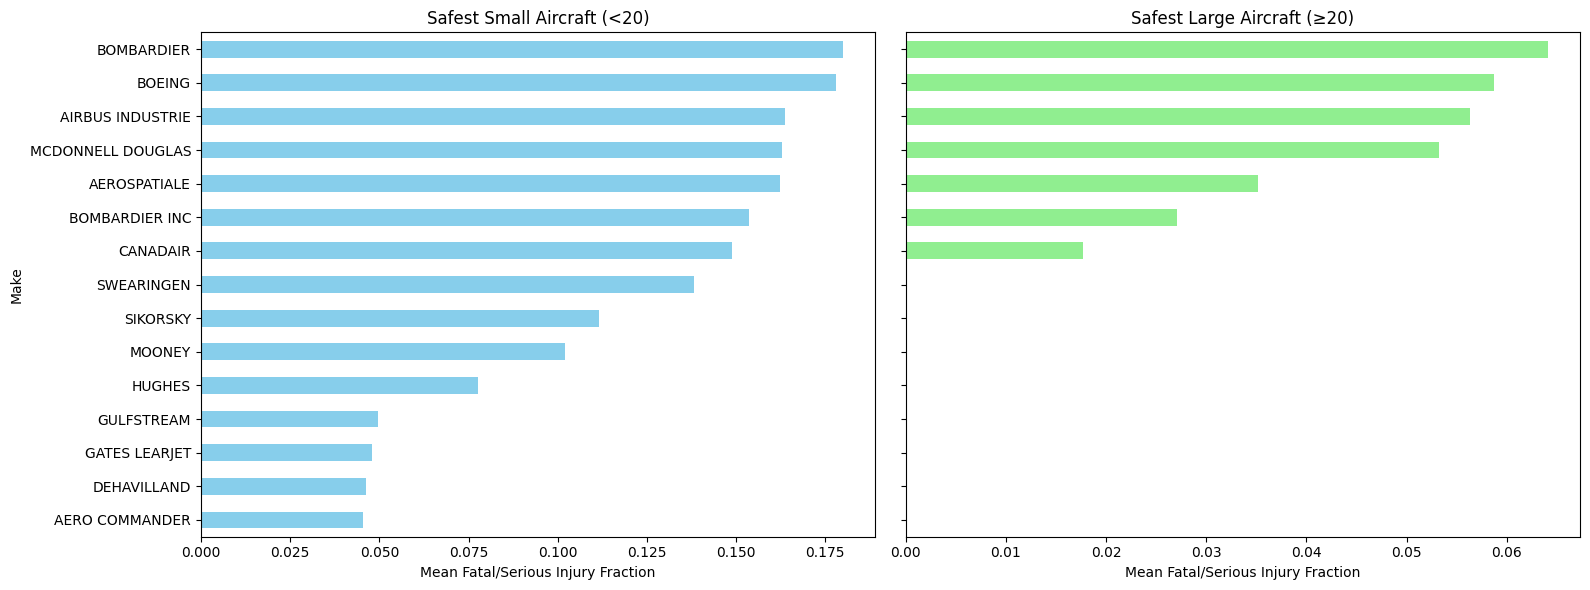

In [9]:
# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16,6), sharey=True)

top15_small.plot(kind='barh', ax=axes[0], color='skyblue', title="Safest Small Aircraft (<20)")
axes[0].set_xlabel("Mean Fatal/Serious Injury Fraction")

top15_large.plot(kind='barh', ax=axes[1], color='lightgreen', title="Safest Large Aircraft (≥20)")
axes[1].set_xlabel("Mean Fatal/Serious Injury Fraction")

plt.tight_layout()
plt.show()


**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

C:\Users\Admin\AppData\Local\Temp\ipykernel_32208\3559148338.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Make', y='FatalSeriousFraction', data=subset, inner='quartile', palette='Set2')


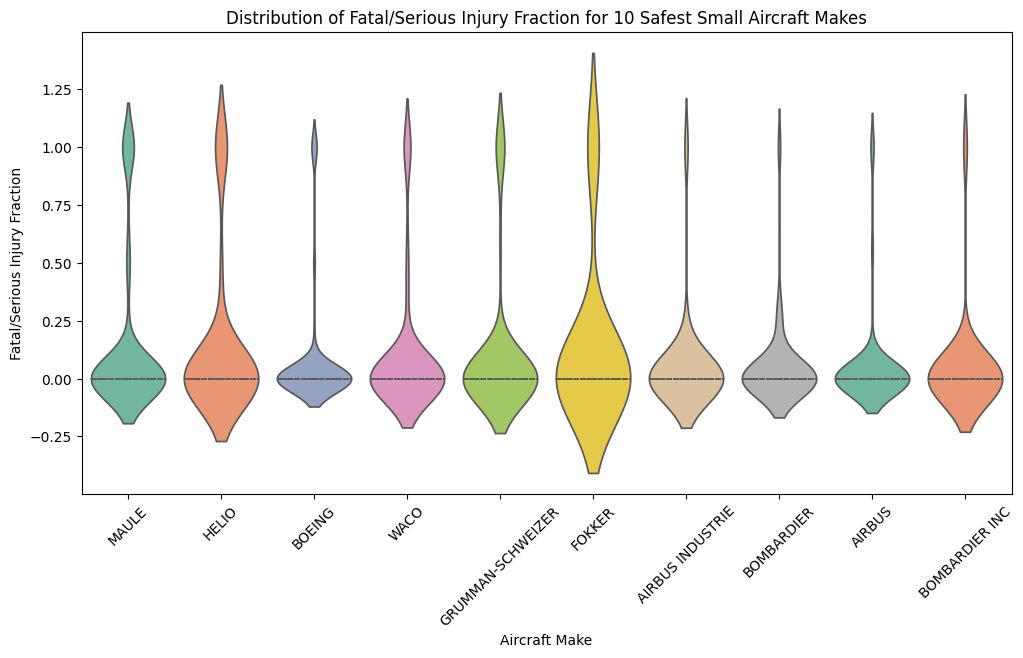

In [10]:
#combined metric
aviation_df['FatalSeriousFraction'] = aviation_df['FatalRate'] + aviation_df['SeriousRate']

#filter small aircraft
small_aircraft = aviation_df[aviation_df['Total.Occupants'] < 20]

#compute mean FatalSeriousFraction per make
mean_by_make = (small_aircraft.groupby('Make')['FatalSeriousFraction']
                .mean()
                .sort_values())

#select 10 makes with lowest mean values
top10_makes = mean_by_make.head(10).index

#filter dataset to only those makes
subset = small_aircraft[small_aircraft['Make'].isin(top10_makes)]

#violinplot
plt.figure(figsize=(12,6))
sns.violinplot(x='Make', y='FatalSeriousFraction', data=subset, inner='quartile', palette='Set2')
plt.xticks(rotation=45)
plt.title("Distribution of Fatal/Serious Injury Fraction for 10 Safest Small Aircraft Makes")
plt.ylabel("Fatal/Serious Injury Fraction")
plt.xlabel("Aircraft Make")
plt.show()


**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

C:\Users\Admin\AppData\Local\Temp\ipykernel_32208\4006346401.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='Make', y='FatalSeriousFraction', data=subset_large, jitter=True, palette='Set1')


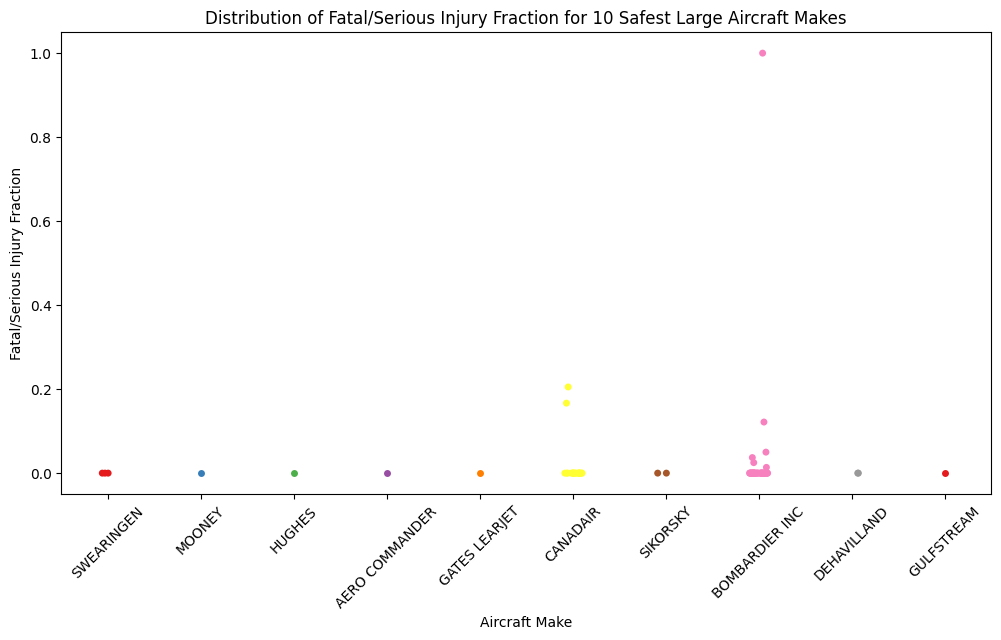

In [11]:
#combined metric
aviation_df['FatalSeriousFraction'] = aviation_df['FatalRate'] + aviation_df['SeriousRate']

#filter for large aircraft 
large_aircraft = aviation_df[aviation_df['Total.Occupants'] >= 20]

# Compute mean FatalSeriousFraction per make
mean_by_make_large = (large_aircraft.groupby('Make')['FatalSeriousFraction']
                      .mean()
                      .sort_values())

#select 10 makes with lowest mean values
top10_large_makes = mean_by_make_large.head(10).index

#filter dataset to only those makes
subset_large = large_aircraft[large_aircraft['Make'].isin(top10_large_makes)]

#stripplot
plt.figure(figsize=(12,6))
sns.stripplot(x='Make', y='FatalSeriousFraction', data=subset_large, jitter=True, palette='Set1')
plt.xticks(rotation=45)
plt.title("Distribution of Fatal/Serious Injury Fraction for 10 Safest Large Aircraft Makes")
plt.ylabel("Fatal/Serious Injury Fraction")
plt.xlabel("Aircraft Make")
plt.show()


**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [12]:
#small aircraft destruction rates
small_destruction = (small_aircraft.groupby('Make')['Destroyed']
                     .mean()
                     .nsmallest(15))

#large aircraft destruction rates
large_destruction = (large_aircraft.groupby('Make')['Destroyed']
                     .mean()
                     .nsmallest(15))

print("Lowest 15 destruction rates for small aircrafts:")
print(small_destruction)

print("Lowest 15 destruction rates for large aircrafts:")
print(large_destruction)


Lowest 15 destruction rates for small aircrafts:
Make
AERO COMMANDER                0.0
AERONCA                       0.0
AEROSPATIALE                  0.0
AEROSTAR                      0.0
AGUSTA                        0.0
AIR TRACTOR                   0.0
AIR TRACTOR INC               0.0
AIRBUS                        0.0
AIRBUS INDUSTRIE              0.0
AMERICAN                      0.0
AMERICAN CHAMPION AIRCRAFT    0.0
AVIAT                         0.0
AVIAT AIRCRAFT INC            0.0
AYRES                         0.0
BALLOON WORKS                 0.0
Name: Destroyed, dtype: float64
Lowest 15 destruction rates for large aircrafts:
Make
AERO COMMANDER       0.0
AEROSPATIALE         0.0
AIRBUS               0.0
AIRBUS INDUSTRIE     0.0
BEECHCRAFT           0.0
BELL                 0.0
BOEING               0.0
BOMBARDIER           0.0
BOMBARDIER INC       0.0
BRITISH AEROSPACE    0.0
CAMERON              0.0
CANADAIR             0.0
CESSNA               0.0
DE HAVILLAND         0.0


#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

The dataframe has been split into 2; small aircraft and large aircraft. 

Through analysis, there is a difference in safety performance across the makes.

Small aircraft show lower fatal/serious injury rates and low destruction rates. Through the violin plot, we however see that despite the low averages, there is wider distributions; showing that there are occasional severe accidents<br>
Our reccomendation would be to prioritize makes with both low averages and tight distributions for insurance, as they seem more reliable safety wise.

Large aircraft show clusters of low injury fractions, with higher variability. This means that overall destruction rates are lower but there are some outstanding makes. Prioritize low destruction fractions ans stable injury outcomes.



### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

C:\Users\Admin\AppData\Local\Temp\ipykernel_32208\1618917183.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_large.index, y=mean_large.values, palette='Greens')


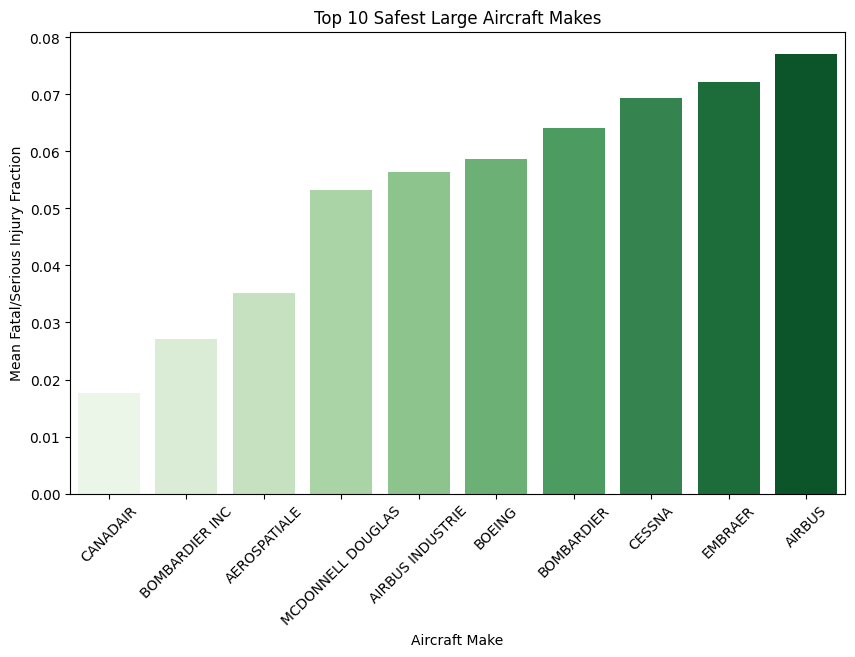

In [13]:
# ensure at least 10 accidents per make
make_counts_large = large_aircraft['Make'].value_counts()
valid_large_makes = make_counts_large[make_counts_large >= 10].index
large_aircraft = large_aircraft[large_aircraft['Make'].isin(valid_large_makes)]

# Compute mean fatal/serious fraction per make
mean_large = (large_aircraft.groupby('Make')['FatalSeriousFraction']
              .mean()
              .sort_values()
              .head(10))

# Plot bar chart
plt.figure(figsize=(10,6))
sns.barplot(x=mean_large.index, y=mean_large.values, palette='Greens')
plt.xticks(rotation=45)
plt.title("Top 10 Safest Large Aircraft Makes")
plt.ylabel("Mean Fatal/Serious Injury Fraction")
plt.xlabel("Aircraft Make")
plt.show()


**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

C:\Users\Admin\AppData\Local\Temp\ipykernel_32208\2401402141.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_small.index, y=mean_small.values, palette='Blues')


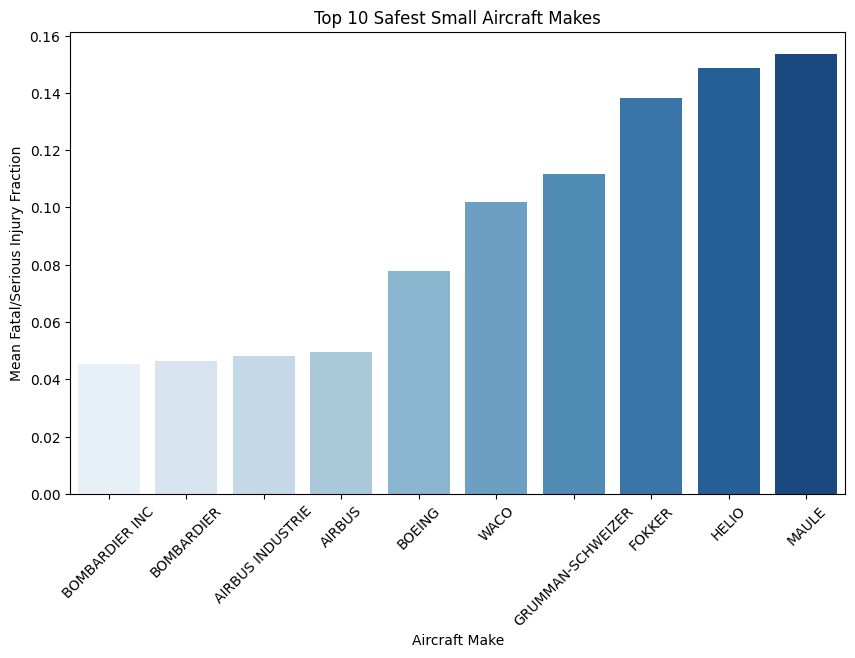

In [14]:
# Ensure at least 10 accidents per make
make_counts_small = small_aircraft['Make'].value_counts()
valid_small_makes = make_counts_small[make_counts_small >= 10].index
small_aircraft = small_aircraft[small_aircraft['Make'].isin(valid_small_makes)]

# Compute mean fatal/serious fraction per make
mean_small = (small_aircraft.groupby('Make')['FatalSeriousFraction']
              .mean()
              .sort_values()
              .head(10))

# Plot bar chart
plt.figure(figsize=(10,6))
sns.barplot(x=mean_small.index, y=mean_small.values, palette='Blues')
plt.xticks(rotation=45)
plt.title("Top 10 Safest Small Aircraft Makes")
plt.ylabel("Mean Fatal/Serious Injury Fraction")
plt.xlabel("Aircraft Make")
plt.show()


### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

Small aircraft have shown lower mean fatal/serious injury fractions, however even among safer makes, occassional severe accidents occur. Averages should not be the only basis of decisions since the information from the bar graph is not as nuanced as the violin plots. Most reliable makes have low averages and narrow distributions.

Large aircraft have lower destruction rates. 

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

C:\Users\Admin\AppData\Local\Temp\ipykernel_32208\4007898544.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Weather.Condition', y='FatalSeriousFraction', data=weather_stats, palette="pastel")


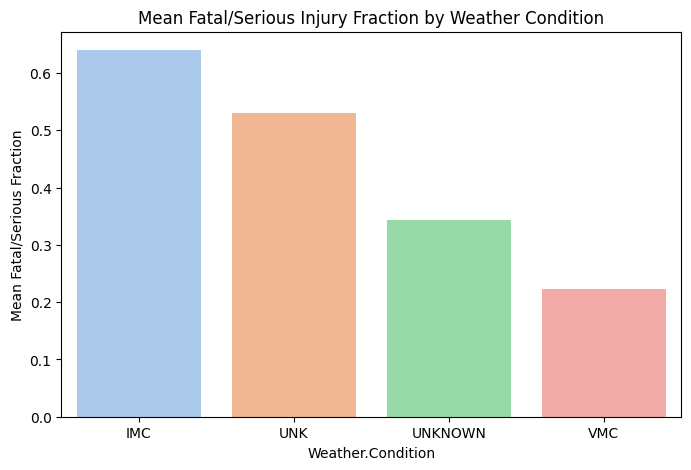

C:\Users\Admin\AppData\Local\Temp\ipykernel_32208\4007898544.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Weather.Condition', y='Destroyed', data=weather_stats, palette="Greens")


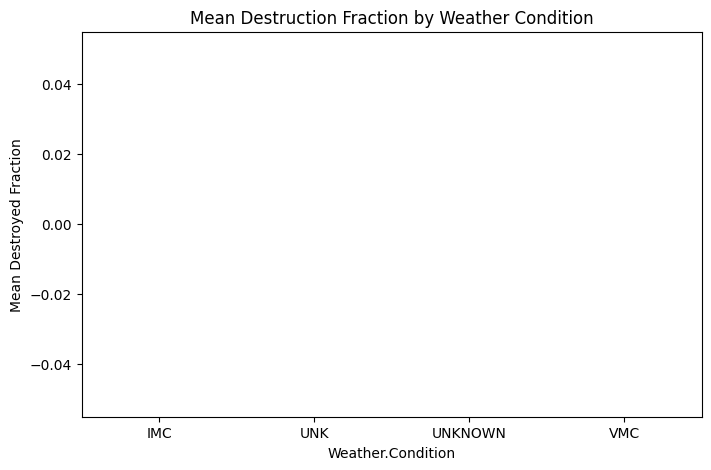

In [15]:
#Group by Weather Condition
weather_stats = aviation_df.groupby('Weather.Condition')[['FatalSeriousFraction','Destroyed']].mean().reset_index()
# Plot mean fatal/serious injury fraction
plt.figure(figsize=(8,5))
sns.barplot(x='Weather.Condition', y='FatalSeriousFraction', data=weather_stats, palette="pastel")
plt.title("Mean Fatal/Serious Injury Fraction by Weather Condition")
plt.ylabel("Mean Fatal/Serious Fraction")
plt.show()
# Plot mean destruction fraction
plt.figure(figsize=(8,5))
sns.barplot(x='Weather.Condition', y='Destroyed', data=weather_stats, palette="Greens")
plt.title("Mean Destruction Fraction by Weather Condition")
plt.ylabel("Mean Destroyed Fraction")
plt.show()


C:\Users\Admin\AppData\Local\Temp\ipykernel_32208\2267504504.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Broad.phase.of.flight', y='FatalSeriousFraction', data=aviation_df, palette="muted", inner='quartile')


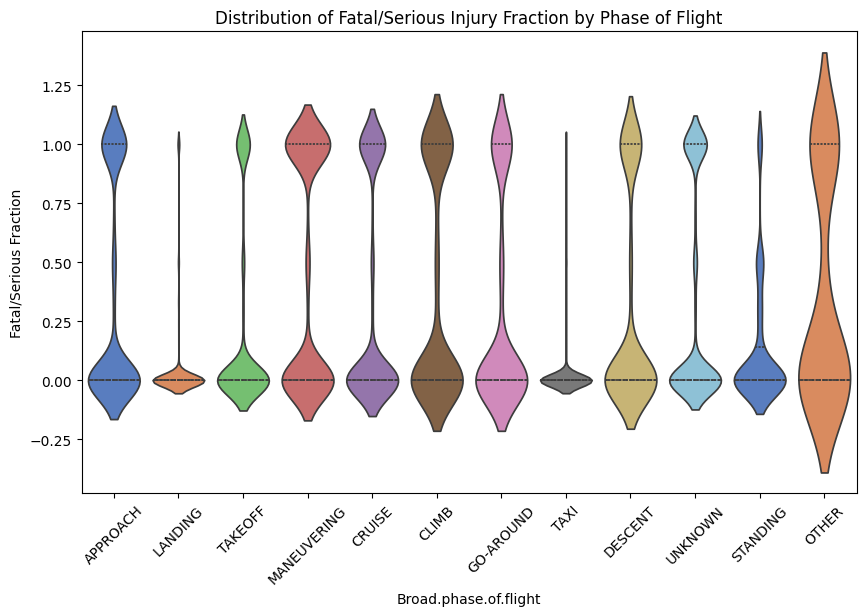

In [16]:
# Violin plot for distribution of fatal/serious injury fraction by phase of flight
plt.figure(figsize=(10,6))
sns.violinplot(x='Broad.phase.of.flight', y='FatalSeriousFraction', data=aviation_df, palette="muted", inner='quartile')
plt.xticks(rotation=45)
plt.title("Distribution of Fatal/Serious Injury Fraction by Phase of Flight")
plt.ylabel("Fatal/Serious Fraction")
plt.show()
